# ssDNA-Hi-C Analysis Pipeline Tutorial

This notebook runs the complete **sshicstuff** pipeline on a `.cool` contact matrix,
from input validation to aggregated 4C-like profiles around centromeres and telomeres.

Each cell mirrors the corresponding `test-scripts/C0x_*.sh` shell script and maps directly
to a CLI subcommand exposed in `commands.py`.

In [3]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = '4'
os.environ.pop("MPLBACKEND", None)

import glob
import pandas as pd
from os.path import join

## 1. Pipeline inputs

Each run of the pipeline requires the following input files:

| Flag | Description |
|---|---|
| `-m / --matrix` | `.cool` contact matrix produced by *hicstuff*. |
| `-c / --oligo-capture` | CSV file describing capture oligos (probes): chrom, start, end, name, sequence. See the **design tutorial** for how to build it. |
| `-C / --chr-coord` | TSV with chromosome names, lengths, and centromere / telomere positions. Used for rebinning and aggregation. |
| `-a / --additional-groups` | *(optional)* Probe grouping file for custom probe sets or aggregation regions. |

Key optional flags:

| Flag | Default | Description |
|---|---|---|
| `-b / --bin-size` | — | Binning size(s) for rebinning (e.g. 1000, 10000 bp). Repeatable. |
| `-F / --force` | off | Overwrite existing output files. |
| `-N / --normalize` | off | Normalize contact frequencies. |
| `-n / --flanking` | 2 | Number of flanking fragments removed around ssDNA probes. |
| `-o / --output` | — | Output directory (or file path, depending on the subcommand). |
| `-r / --cis-range` | 50000 | Cis interaction distance in bp used for statistics. |
| `--bin-cen` | 10000 | Bin size (bp) used for centromere aggregation. |
| `--bin-telo` | 1000 | Bin size (bp) used for telomere aggregation. |
| `--window-cen` | 150000 | Aggregation window size (bp) around centromeres. |
| `--window-telo` | 15000 | Aggregation window size (bp) around telomeres. |
| `--copy-inputs` | off | Copy input files into the output directory for reproducibility. |

In [4]:
# ── Directories ────────────────────────────────────────────────────────────────
INPUTS_DIR  = "../test-data/inputs"
SAMPLE      = "AD433_sub4M"
OUTPUTS_DIR = f"../test-data/C-output-sshicstuff/{SAMPLE}"
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── Input files (mirrors C00_set_variables.sh) ─────────────────────────────────
cool    = f"{SAMPLE}.cool"
capture = "capture_oligo_positions.csv"
coords  = "chr_coordinates_for_pipeline.tsv"
groups  = "additional_probe_groups.tsv"

COOL_INPUT      = join(INPUTS_DIR, cool)
CAPTURE_OLIGOS  = join(INPUTS_DIR, capture)
CHROM_COORDS    = join(INPUTS_DIR, coords)
GROUPS_TABLE    = join(INPUTS_DIR, groups)

# ── Output paths (mirrors C00_set_variables.sh) ────────────────────────────────
CAPTURE_ASSOCIATED    = join(OUTPUTS_DIR, "capture_oligo_positions_fragments_associated.csv")

DSDNA_COOL            = join(OUTPUTS_DIR, f"{SAMPLE}_dsdna_only.cool")
SSDNA_COOL            = join(OUTPUTS_DIR, f"{SAMPLE}_ssdna_only.cool")
SSDNA_TO_SSDNA_COOL   = join(OUTPUTS_DIR, f"{SAMPLE}_ssdna_to_ssdna_only.cool")

FILTERED_COOL         = join(OUTPUTS_DIR, f"{SAMPLE}_filtered.cool")
FILTERED_TSV          = join(OUTPUTS_DIR, f"{SAMPLE}_filtered.tsv")

COVERAGE_FRAGMENT     = join(OUTPUTS_DIR, f"{SAMPLE}_coverage.counts.fragment_level.bedgraph")
COVERAGE_5KB          = join(OUTPUTS_DIR, f"{SAMPLE}_coverage.counts.5kb.bedgraph")

PROBE2PROBE_MATRIX    = join(OUTPUTS_DIR, f"{SAMPLE}_probe_matrix.tsv")
PROBE2PROBE_PLOT      = join(OUTPUTS_DIR, f"{SAMPLE}_probe_matrix.png")
PROBE2PROBE_COOL      = join(OUTPUTS_DIR, f"{SAMPLE}_probe_matrix.cool")

PROFILE_0KB_CONTACTS  = join(OUTPUTS_DIR, f"{SAMPLE}_0kb_profile_contacts.tsv")
PROFILE_0KB_FREQ      = join(OUTPUTS_DIR, f"{SAMPLE}_0kb_profile_frequencies.tsv")
PROFILE_1KB_FREQ      = join(OUTPUTS_DIR, f"{SAMPLE}_1kb_profile_frequencies.tsv")
PROFILE_10KB_FREQ     = join(OUTPUTS_DIR, f"{SAMPLE}_10kb_profile_frequencies.tsv")

STATS_TABLE           = join(OUTPUTS_DIR, f"{SAMPLE}_statistics.tsv")
CHR_FREQ_TABLE        = join(OUTPUTS_DIR, f"{SAMPLE}_norm_chr_freq.tsv")
INTER_CHR_FREQ_TABLE  = join(OUTPUTS_DIR, f"{SAMPLE}_norm_inter_chr_freq.tsv")

print(f"INPUTS_DIR  = {INPUTS_DIR}")
print(f"OUTPUTS_DIR = {OUTPUTS_DIR}")
print(f"COOL_INPUT  = {COOL_INPUT}")

INPUTS_DIR  = ../test-data/inputs
OUTPUTS_DIR = ../test-data/C-output-sshicstuff/AD433_sub4M
COOL_INPUT  = ../test-data/inputs/AD433_sub4M.cool


## 2. Pipeline overview

The notebook calls each subcommand in the same order as the full `pipeline` subcommand:

| Step | Shell script | Subcommand |
|---|---|---|
| 1 | `C01_associate_probes.sh` | `associate` |
| 2 | `C02_extract_dsdna_only.sh` | `dsdnaonly` |
| 3 | `C03_extract_ssdna_only.sh` | `ssdnaonly` |
| 4 | `C04_compute_coverage.sh` | `coverage` |
| 5 | `C05_filter_contacts.sh` | `filter` |
| 6 | `C06_probe_to_probe.sh` | `probe2probe` |
| 7 | `C07_build_profiles.sh` | `profile` + `plot4c` |
| 8 | `C08_rebin_profiles.sh` | `rebin` + `plot4c` |
| 9 | `C09_compute_stats.sh` | `stats` |
| 10 | `C10_aggregate_centromeres.sh` | `aggregate --cen` |
| 11 | `C11_aggregate_telomeres.sh` | `aggregate --tel` |

## Step 1 — Associate probes to restriction fragments

Each probe midpoint is matched to its closest restriction fragment on the same chromosome
(derived from the `.cool` bin table).
Three columns are appended to the oligo table: `fragment`, `fragment_start`, `fragment_end`.

**Output:** `capture_oligo_positions_fragments_associated.csv`

In [3]:
# Mirrors C01_associate_probes.sh
cmd = (
    f"sshicstuff associate"
    f" -m {COOL_INPUT}"
    f" -c {CAPTURE_OLIGOS}"
    f" -o {CAPTURE_ASSOCIATED}"
)
!{cmd}

df_associated = pd.read_csv(CAPTURE_ASSOCIATED)
df_associated[["name", "fragment", "fragment_start", "fragment_end"]].head()

INFO :: [Associate] Mapping probes to restriction fragments (cool).
INFO :: [Associate] Written: capture_oligo_positions_fragments_associated.csv


,name,fragment,fragment_start,fragment_end
0,Native_URA-L-17213-MfeI-RC,74823,0,289
1,Native_URA-L-16220-MfeI-RC,74824,289,655
2,Native_URA-L-15683-SspI-RC,74825,655,1021
3,Native_URA-L-9924-MfeI-RC,74826,1021,1387
4,Native_URA-L-6532-MfeI-RC,74827,1387,1727


## Step 2 — Extract dsDNA-only matrix

Keeps only contacts where **neither** read end overlaps a ssDNA probe fragment.

**Output:** `{SAMPLE}_dsdna_only.cool`

In [4]:
# Mirrors C02_extract_dsdna_only.sh
cmd = (
    f"sshicstuff dsdnaonly"
    f" -m {COOL_INPUT}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -o {OUTPUTS_DIR}"
    f" -F"
)
!{cmd}
print(f"Output: {DSDNA_COOL}")

INFO :: [dsDNA-only] Excluded 70011 / 1256317 pixels touching a probe fragment (±2).
INFO :: [Subset2Cool] 1186306 pixels → AD433_sub4M_dsdna_only.cool
Output: ../test-data/C-output-sshicstuff/AD433_sub4M/AD433_sub4M_dsdna_only.cool


## Step 3 — Extract ssDNA-only matrices

Produces two matrices:
- **ssDNA-only**: contacts where at least one end is a ssDNA probe fragment.
- **ssDNA-to-ssDNA**: contacts where **both** ends are ssDNA probe fragments.

**Outputs:** `{SAMPLE}_ssdna_only.cool`, `{SAMPLE}_ssdna_to_ssdna_only.cool`

In [5]:
# Mirrors C03_extract_ssdna_only.sh
cmd = (
    f"sshicstuff ssdnaonly"
    f" -m {COOL_INPUT}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -o {OUTPUTS_DIR}"
    f" -F"
)
!{cmd}
print(f"Output: {SSDNA_COOL}")
print(f"Output: {SSDNA_TO_SSDNA_COOL}")

INFO :: [ssDNA-only] : Keeping 230 / 1256317 pixels where both bins are ssDNA probes.
INFO :: [ssDNA-only] : Keeping 40867 / 1256317 pixels where at least one bin is an ssDNA probe.
INFO :: [Subset2Cool] 230 pixels → AD433_sub4M_ssdna_to_ssdna_only.cool
INFO :: [Subset2Cool] 40867 pixels → AD433_sub4M_ssdna_only.cool
Output: ../test-data/C-output-sshicstuff/AD433_sub4M/AD433_sub4M_ssdna_only.cool
Output: ../test-data/C-output-sshicstuff/AD433_sub4M/AD433_sub4M_ssdna_to_ssdna_only.cool


## Step 4 — Compute coverage

Coverage is computed at two resolutions:
1. **Fragment level** — one value per restriction fragment.
2. **5 kb bins** — fragments spanning bin edges are proportionally split.

**Outputs:** `{SAMPLE}_coverage.counts.fragment_level.bedgraph`, `{SAMPLE}_coverage.counts.5kb.bedgraph`

In [6]:
# Mirrors C04_compute_coverage.sh — fragment level
cmd = (
    f"sshicstuff coverage"
    f" -m {COOL_INPUT}"
    f" -o {OUTPUTS_DIR}"
    f" -F"
)
!{cmd}

df_cov_frag = pd.read_table(COVERAGE_FRAGMENT, header=None, names=["chrom", "start", "end", "count"])
df_cov_frag.head()

INFO :: [Coverage] BedGraph → AD433_sub4M_coverage.counts.fragment_level.bedgraph


,chrom,start,end,count
0,chr1,0,336,121
1,chr1,336,476,41
2,chr1,476,509,3
3,chr1,509,1149,116
4,chr1,1149,1410,111


In [7]:
# Mirrors C04_compute_coverage.sh — 5 kb bins
cmd = (
    f"sshicstuff coverage"
    f" -m {COOL_INPUT}"
    f" -c {CHROM_COORDS}"
    f" -b 5000"
    f" -o {OUTPUTS_DIR}"
    f" -F"
)
!{cmd}

df_cov_5kb = pd.read_table(COVERAGE_5KB, header=None, names=["chrom", "start", "end", "count"])
df_cov_5kb.head()

INFO :: [Coverage] BedGraph → AD433_sub4M_coverage.counts.5kb.bedgraph


,chrom,start,end,count
0,chr1,0,5000,1066.971429
1,chr1,5000,10000,1054.919622
2,chr1,10000,15000,795.767593
3,chr1,15000,20000,939.410322
4,chr1,20000,25000,733.097701


## Step 5 — Filter to probe-bearing contacts

Reads the `.cool` matrix and keeps only contacts where at least one end overlaps a probe fragment.
The result is written as a tidy TSV (one row per contact pair, with per-side probe metadata)
and as a filtered `.cool`.

**Outputs:** `{SAMPLE}_filtered.cool`, `{SAMPLE}_filtered.tsv`

In [8]:
# Mirrors C05_filter_contacts.sh
cmd = (
    f"sshicstuff filter"
    f" -m {COOL_INPUT}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -o {FILTERED_COOL}"
    f" -t {FILTERED_TSV}"
    f" -F"
)
!{cmd}

df_filtered = pd.read_table(FILTERED_TSV)
df_filtered.head()

INFO :: [Filter] Keeping 63191 / 1256317 pixels touching a probe fragment.
INFO :: [Subset2Cool] 63191 pixels → AD433_sub4M_filtered.cool
INFO :: [Filter] Filtered cool → AD433_sub4M_filtered.cool
INFO :: [Filter] Joined TSV  → AD433_sub4M_filtered.tsv


,frag_a,frag_b,contacts,chr_a,start_a,end_a,size_a,name_a,type_a,sequence_a,chr_b,start_b,end_b,size_b,name_b,type_b,sequence_b
0,0,74851,1,chr1,0,336,336,NaN,NaN,NaN,chr_artificial_ssDNA,1387,1753,366,Probe_URA-L-6532-MfeI-RC,ss,TTCTTGACTTgCTTCTTCTTTGGATaCTACATTTGTGCCAtTTGTA...
1,0,74854,1,chr1,0,336,336,NaN,NaN,NaN,chr_artificial_ssDNA,2485,2851,366,Probe_URA-L-3728-SspI-RC,ss,tTCTAATAGTCCTAGGACaCACATGAAGTaCTCATTTGTCAAAtTA...
2,0,74858,1,chr1,0,336,336,NaN,NaN,NaN,chr_artificial_ssDNA,3949,4315,366,Probe_URA-L-774-MfeI-RC,ss,GAGTAGGGACATACAtTTGGGCACCTAAAAATAATGGTGTAAACAT...
3,1,74862,1,chr1,336,476,140,NaN,NaN,NaN,chr_artificial_ssDNA,5413,5779,366,Probe_URA-R-8073-SspI,ss,cCTGTGCTTTCTGTTAcCGTATTGGAAtTATTTCCAGCTaGtGTCG...
4,2,74855,2,chr1,476,509,33,NaN,NaN,NaN,chr_artificial_ssDNA,2851,3217,366,Probe_URA-L-3081-MfeI-RC,ss,TaAATTGGCGCAGTAGCCTCAATTTCAACGTCGTTTGcCTCTGGTG...


## Step 6 — Build the probe-to-probe matrix

Builds a symmetric **probe × probe** contact matrix restricted to contacts where both ends
are probe fragments. Useful for QC and probe clustering.

Flags used here:
- `--normalize` — divide counts by the total to get relative frequencies.
- `-P` — produce a heatmap plot.
- `--export-to-cooler` — also write a `.cool` file (enables the visualization cell below).

**Outputs:** `{SAMPLE}_probe_matrix.tsv`, `{SAMPLE}_probe_matrix.png`, `{SAMPLE}_probe_matrix.cool`

INFO :: [ProbeMatrix] 49 × 49 → AD433_sub4M_probe_matrix.tsv
INFO :: [ProbeMatrix2Cooler] → AD433_sub4M_probe_matrix.cool
INFO :: [ProbeMatrix2Cooler] Bin mapping → AD433_sub4M_probe_matrix_bins.tsv
INFO :: [Plot] Probe matrix heatmap → AD433_sub4M_probe_matrix.png


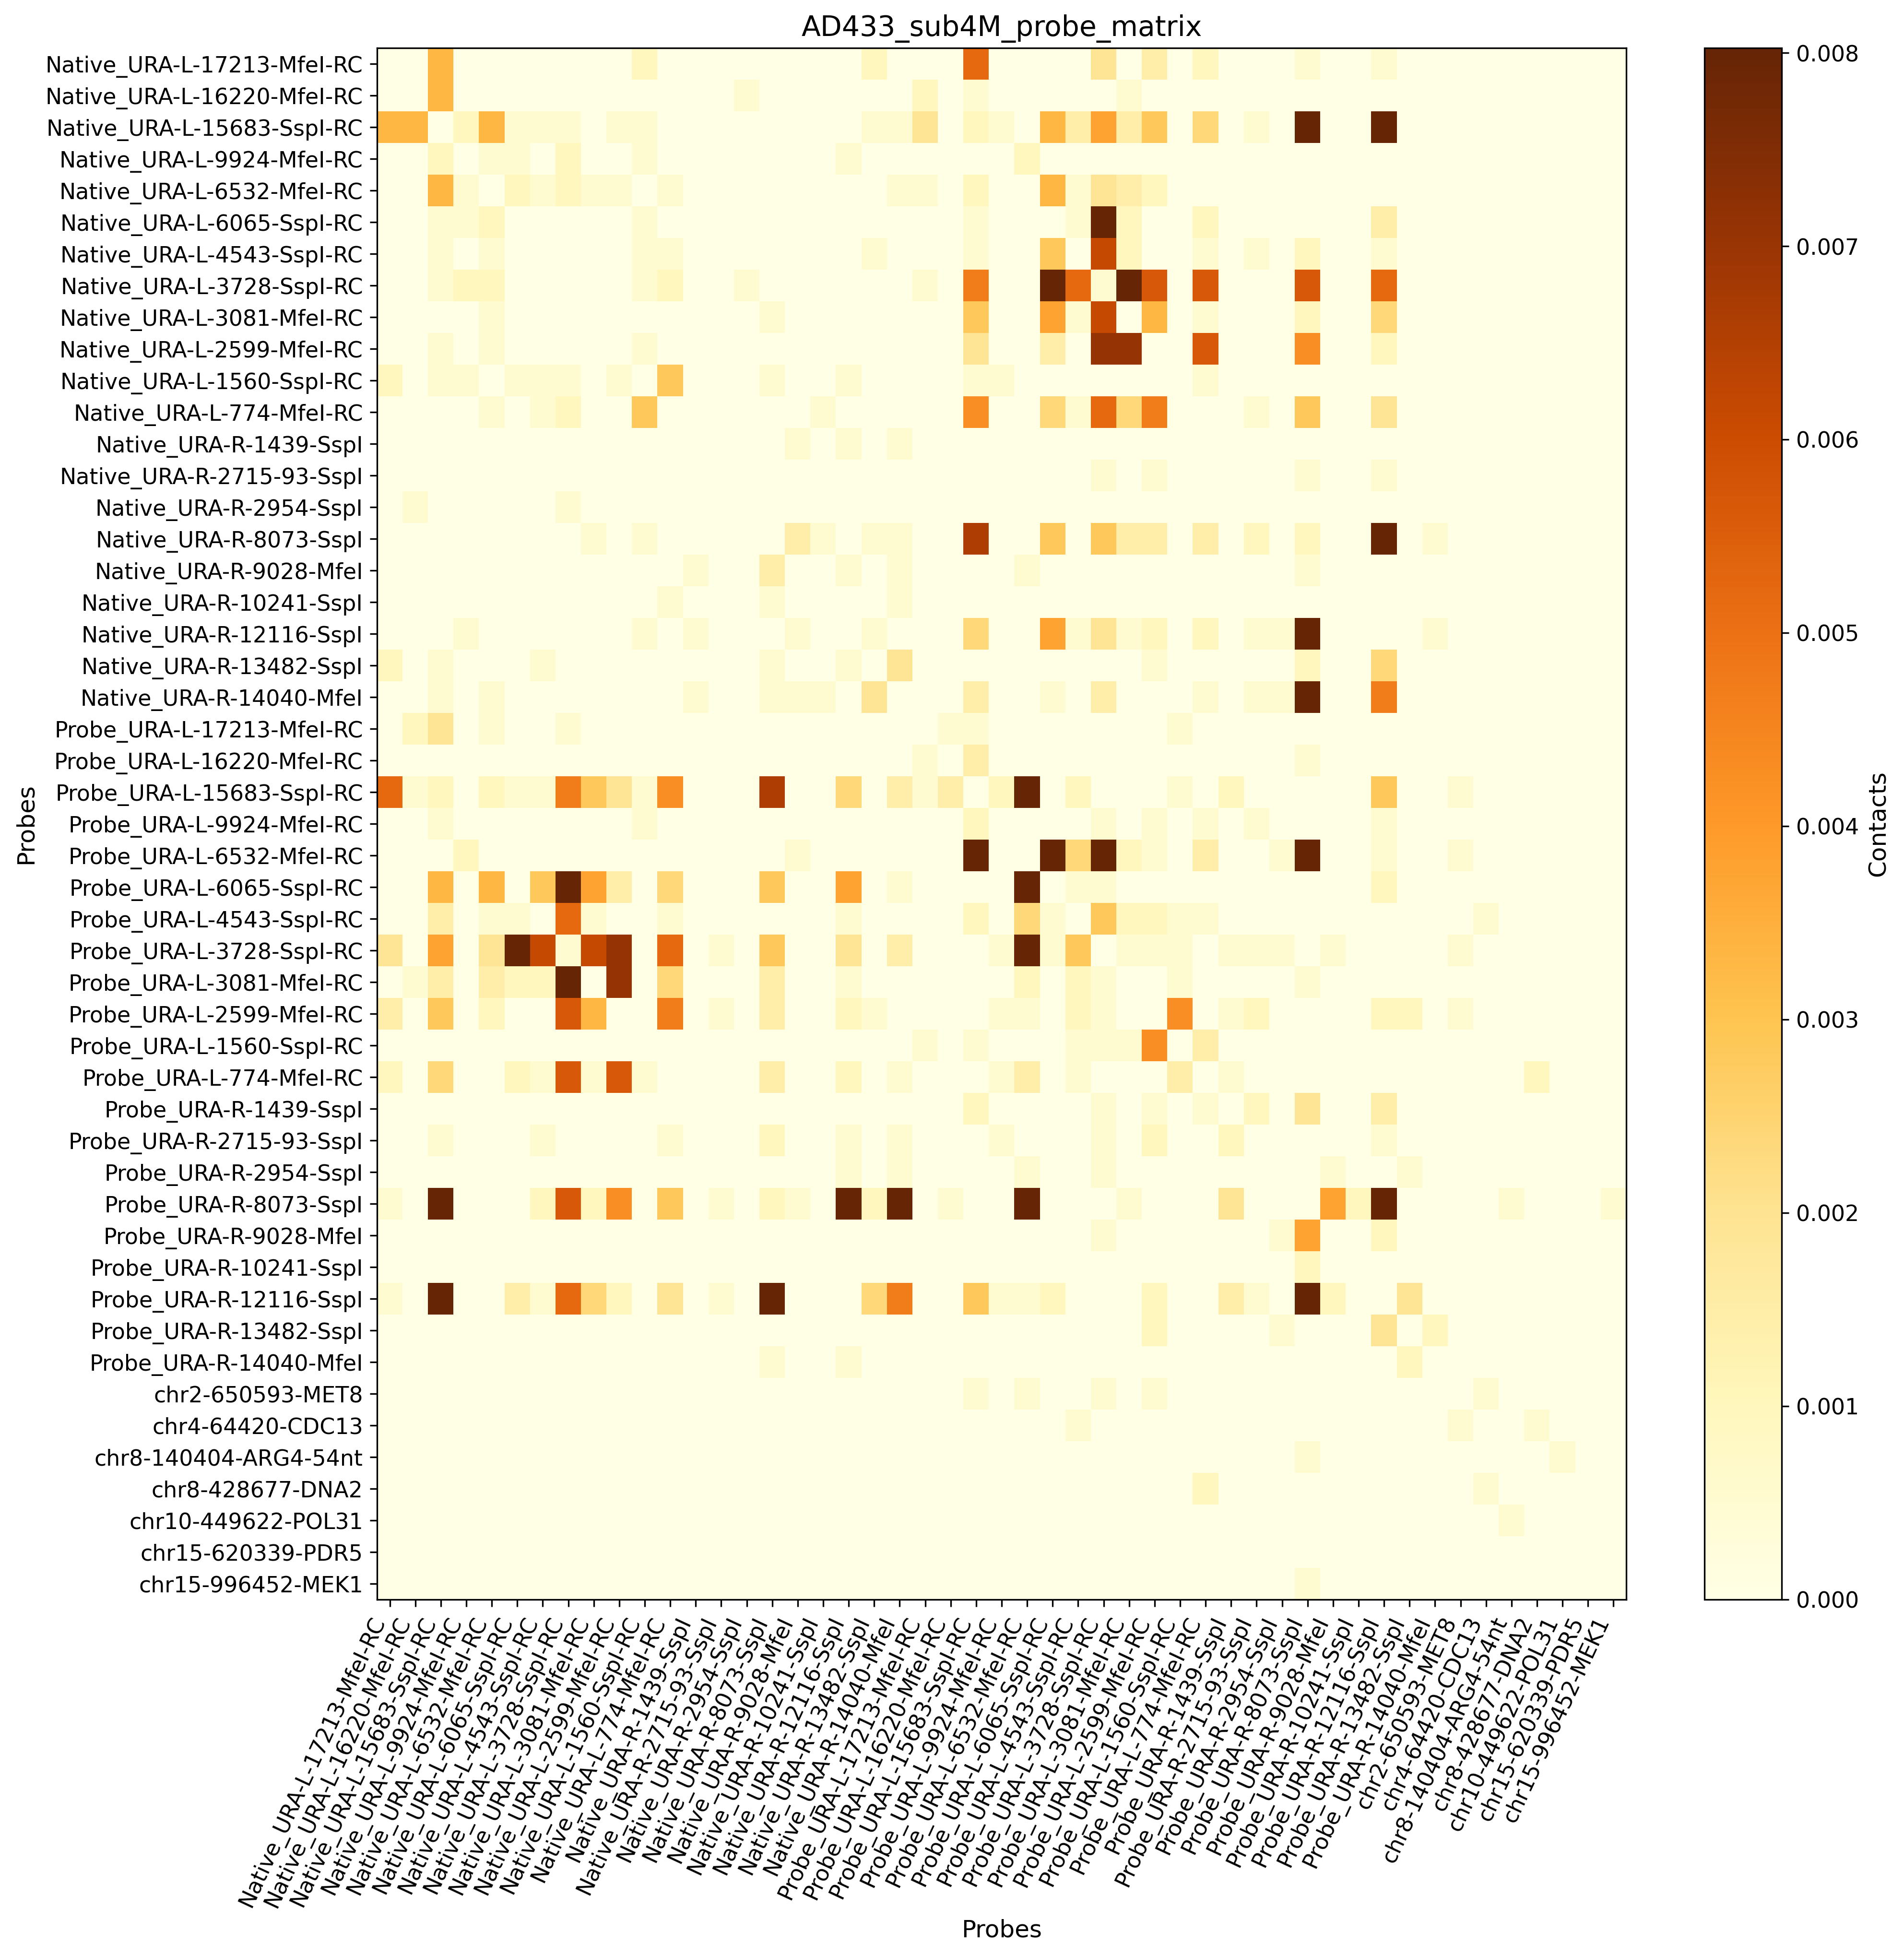

In [11]:
# Mirrors C06_probe_to_probe.sh (+ --export-to-cooler for the visualization below)
cmd = (
    f"sshicstuff probe2probe"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -f {FILTERED_TSV}"
    f" -o {PROBE2PROBE_MATRIX}"
    f" --normalize"
    f" -P"
    f" --plot-format png"
    f" --colormap YlOrBr"
    f" -F"
)
!{cmd}

from IPython.display import Image
Image(PROBE2PROBE_PLOT)

### Reading the exported `.cool` file *(optional)*

The probe-to-probe matrix exported to `.cool` encodes each probe as a synthetic bin on an
artificial chromosome (`probes`). A companion `*_bins.tsv` file maps each `bin_id` to the
corresponding probe name and fragment.

Both files are required together for interpretation and visualization.

Cooler bins (first 5):


,chrom,start,end
0,probes,0,1
1,probes,1,2
2,probes,2,3
3,probes,3,4
4,probes,4,5


Probe annotation table (first 5):


,bin_id,probe,fragment
0,0,Native_URA-L-17213-MfeI-RC,74823
1,1,Native_URA-L-16220-MfeI-RC,74824
2,2,Native_URA-L-15683-SspI-RC,74825
3,3,Native_URA-L-9924-MfeI-RC,74826
4,4,Native_URA-L-6532-MfeI-RC,74827


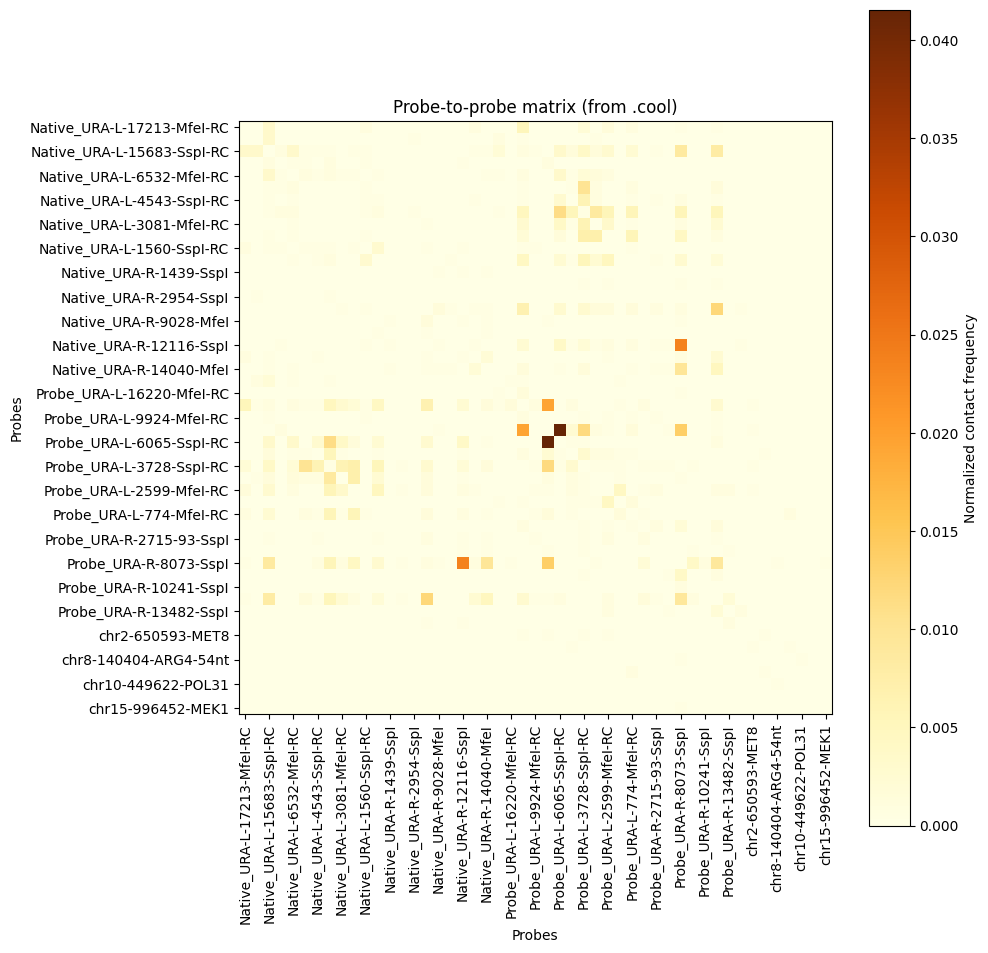

In [5]:
import cooler
import matplotlib.pyplot as plt

PROBE2PROBE_BINS = PROBE2PROBE_COOL.replace(".cool", "_bins.tsv")

c = cooler.Cooler(PROBE2PROBE_COOL)
mat = c.matrix(balance=False)[:]

df_bins = pd.read_csv(PROBE2PROBE_BINS, sep="\t")
probe_labels = df_bins["probe"].tolist()

print("Cooler bins (first 5):")
display(c.bins()[:5])
print("Probe annotation table (first 5):")
display(df_bins.head())

step = max(1, len(probe_labels) // 20)
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(mat, cmap="YlOrBr", interpolation="none")
plt.colorbar(im, ax=ax, label="Normalized contact frequency")
ax.set_xticks(range(0, len(probe_labels), step))
ax.set_xticklabels(probe_labels[::step], rotation=90)
ax.set_yticks(range(0, len(probe_labels), step))
ax.set_yticklabels(probe_labels[::step])
ax.set_title("Probe-to-probe matrix (from .cool)")
ax.set_xlabel("Probes")
ax.set_ylabel("Probes")
plt.tight_layout()
plt.show()

## Step 7 — Build 4C-like profiles

For each probe, contacts are grouped by genomic position (fragment-level resolution = 0 kb).
Two tables are produced: absolute counts and normalized frequencies.
Profiles are then plotted per probe with `plot4c`.

**Outputs:** `{SAMPLE}_0kb_profile_contacts.tsv`, `{SAMPLE}_0kb_profile_frequencies.tsv`

In [6]:
# Mirrors C07_build_profiles.sh — absolute contacts
cmd = (
    f"sshicstuff profile"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -C {CHROM_COORDS}"
    f" -f {FILTERED_TSV}"
    f" -a {GROUPS_TABLE}"
    f" -o {PROFILE_0KB_CONTACTS}"
    f" -F"
)
!{cmd}

df_profile_contacts = pd.read_table(PROFILE_0KB_CONTACTS)
df_profile_contacts.head()

INFO :: [IO] Saved AD433_sub4M_0kb_profile_contacts.tsv (31929 rows × 65 cols)
INFO :: [Profile] Fragment-level profile → AD433_sub4M_0kb_profile_contacts.tsv


,chr,start,sizes,genome_start,74823,74824,74825,74826,74827,74829,...,$avg_left_0-4kb_noly,$avg_left_0-4kb_ly,$avg_left_0-7kb_noly_pool3,$avg_left_0-7kb_noly_pool6,$avg_ly,$avg_left_0-7kb_ly_pool6,$avg_left_dsb-dist,$avg_right_0-3kb,$avg_right_0-8kb,$avg_right_all
0,chr1,0,336,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333333,0.4,0.25,0.333333,0.5,0.375,0.0,0.0,0.00,0.0
1,chr1,336,140,336,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.00,0.000000,0.0,0.000,0.0,0.0,0.25,0.2
2,chr1,476,33,476,0.0,0.0,0.0,0.0,0.0,0.0,...,0.666667,0.4,0.50,0.333333,0.0,0.250,0.0,0.0,0.00,0.0
3,chr1,509,640,509,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.4,0.00,0.000000,1.0,0.250,0.0,0.0,0.25,0.4
4,chr1,1149,261,1149,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333333,0.6,0.25,0.166667,1.0,0.375,0.0,0.0,0.00,0.0


In [7]:
# Mirrors C07_build_profiles.sh — normalized frequencies
cmd = (
    f"sshicstuff profile"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -C {CHROM_COORDS}"
    f" -f {FILTERED_TSV}"
    f" -a {GROUPS_TABLE}"
    f" -o {PROFILE_0KB_FREQ}"
    f" -N"
    f" -F"
)
!{cmd}

df_profile_freq = pd.read_table(PROFILE_0KB_FREQ)
df_profile_freq.head()

INFO :: [IO] Saved AD433_sub4M_0kb_profile_frequencies.tsv (31929 rows × 65 cols)
INFO :: [Profile] Fragment-level profile → AD433_sub4M_0kb_profile_frequencies.tsv
INFO :: [IO] Saved AD433_sub4M_0kb_profile_frequencies_frequencies.tsv (31929 rows × 65 cols)
INFO :: [Profile] Frequency profile → AD433_sub4M_0kb_profile_frequencies_frequencies.tsv


,chr,start,sizes,genome_start,74823,74824,74825,74826,74827,74829,...,$avg_left_0-4kb_noly,$avg_left_0-4kb_ly,$avg_left_0-7kb_noly_pool3,$avg_left_0-7kb_noly_pool6,$avg_ly,$avg_left_0-7kb_ly_pool6,$avg_left_dsb-dist,$avg_right_0-3kb,$avg_right_0-8kb,$avg_right_all
0,chr1,0,336,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333333,0.4,0.25,0.333333,0.5,0.375,0.0,0.0,0.00,0.0
1,chr1,336,140,336,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.00,0.000000,0.0,0.000,0.0,0.0,0.25,0.2
2,chr1,476,33,476,0.0,0.0,0.0,0.0,0.0,0.0,...,0.666667,0.4,0.50,0.333333,0.0,0.250,0.0,0.0,0.00,0.0
3,chr1,509,640,509,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.4,0.00,0.000000,1.0,0.250,0.0,0.0,0.25,0.4
4,chr1,1149,261,1149,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333333,0.6,0.25,0.166667,1.0,0.375,0.0,0.0,0.00,0.0


INFO :: [Plot] Profiles written to ../test-data/C-output-sshicstuff/AD433_sub4M/plots/0kb/linear
61 plot(s) written to ../test-data/C-output-sshicstuff/AD433_sub4M/plots/0kb/linear/


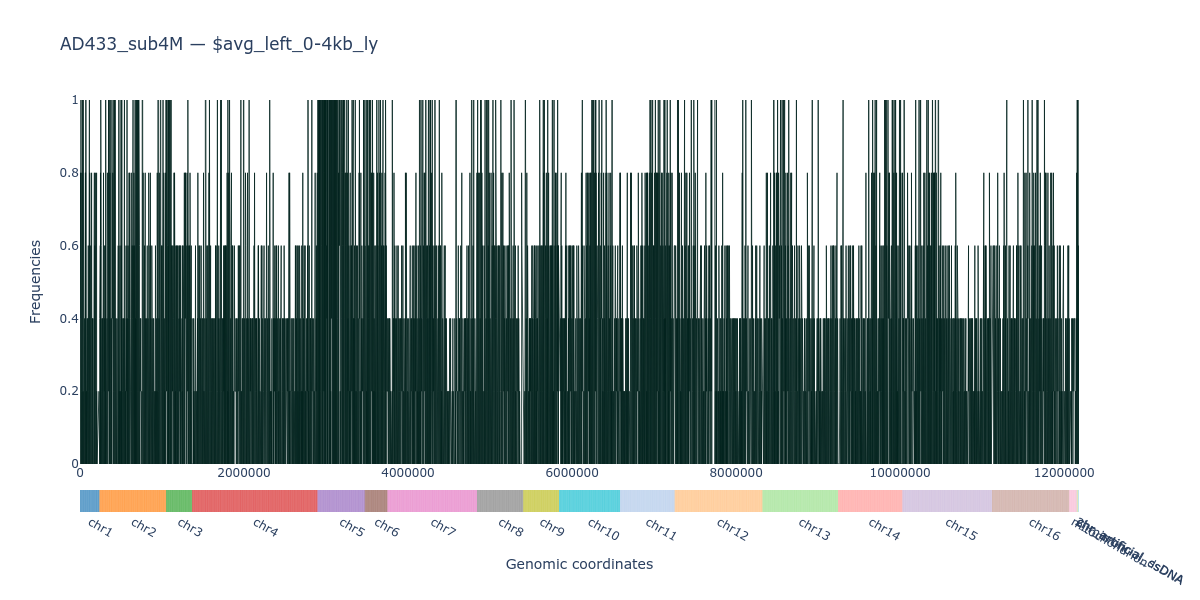

In [9]:
# Mirrors C07_build_profiles.sh — plot4c on the 0 kb normalized profile
cmd = (
    f"sshicstuff plot4c"
    f" -p {PROFILE_0KB_FREQ}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -o {OUTPUTS_DIR}"
    f" -C {CHROM_COORDS}"
    f" -e png"
    f" -H 600"
    f" -W 1200"
    f" -r 4"
    f" -y 0"
    f" -Y 1"
)
!{cmd}

plots_0kb = sorted(glob.glob(join(OUTPUTS_DIR, "plots/0kb/linear/*.png")))
print(f"{len(plots_0kb)} plot(s) written to {join(OUTPUTS_DIR, 'plots/0kb/linear/')}")
if plots_0kb:
    from IPython.display import Image
    display(Image(plots_0kb[0]))

## Step 8 — Rebin profiles

Converts the fragment-level 0 kb profile to fixed-size bins.
Fragments spanning bin edges are proportionally split; missing bins are zero-filled.

**Outputs:** `{SAMPLE}_1kb_profile_frequencies.tsv`, `{SAMPLE}_10kb_profile_frequencies.tsv`

In [10]:
# Mirrors C08_rebin_profiles.sh — 1 kb
cmd = (
    f"sshicstuff rebin"
    f" -p {PROFILE_0KB_FREQ}"
    f" -C {CHROM_COORDS}"
    f" -b 1000"
    f" -o {PROFILE_1KB_FREQ}"
    f" -F"
)
!{cmd}

cmd = (
    f"sshicstuff plot4c"
    f" -p {PROFILE_1KB_FREQ}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -o {OUTPUTS_DIR}"
    f" -C {CHROM_COORDS}"
    f" -e png"
    f" -H 600"
    f" -W 1200"
    f" -r 4"
    f" -y 0"
    f" -Y 0.01"
)
!{cmd}

plots_1kb = sorted(glob.glob(join(OUTPUTS_DIR, "plots/1kb/raw/*.png")))
print(f"{len(plots_1kb)} plot(s) written to {join(OUTPUTS_DIR, 'plots/1kb/raw/')}")
if plots_1kb:
    from IPython.display import Image
    display(Image(plots_1kb[0]))

INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies.tsv (12190 rows × 64 cols)
INFO :: [Rebin] Binned profile (1kb) → AD433_sub4M_1kb_profile_frequencies.tsv
INFO :: [Plot] Profiles written to ../test-data/C-output-sshicstuff/AD433_sub4M/plots/1kb/linear
0 plot(s) written to ../test-data/C-output-sshicstuff/AD433_sub4M/plots/1kb/raw/


In [11]:
# Mirrors C08_rebin_profiles.sh — 10 kb
cmd = (
    f"sshicstuff rebin"
    f" -p {PROFILE_0KB_FREQ}"
    f" -C {CHROM_COORDS}"
    f" -b 10000"
    f" -o {PROFILE_10KB_FREQ}"
    f" -F"
)
!{cmd}

cmd = (
    f"sshicstuff plot4c"
    f" -p {PROFILE_10KB_FREQ}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -o {OUTPUTS_DIR}"
    f" -C {CHROM_COORDS}"
    f" -e png"
    f" -H 600"
    f" -W 1200"
    f" -r 4"
    f" -y 0"
    f" -Y 0.03"
)
!{cmd}

plots_10kb = sorted(glob.glob(join(OUTPUTS_DIR, "plots/10kb/raw/*.png")))
print(f"{len(plots_10kb)} plot(s) written to {join(OUTPUTS_DIR, 'plots/10kb/raw/')}")
if plots_10kb:
    from IPython.display import Image
    display(Image(plots_10kb[0]))

INFO :: [IO] Saved AD433_sub4M_10kb_profile_frequencies.tsv (1228 rows × 64 cols)
INFO :: [Rebin] Binned profile (10kb) → AD433_sub4M_10kb_profile_frequencies.tsv
INFO :: [Plot] Profiles written to ../test-data/C-output-sshicstuff/AD433_sub4M/plots/10kb/linear
0 plot(s) written to ../test-data/C-output-sshicstuff/AD433_sub4M/plots/10kb/raw/


## Step 9 — Per-probe statistics

Computes for each probe:
- total number of contacts and coverage relative to all Hi-C contacts,
- cis vs. trans fractions (controlled by `-r / --cis-range`, default 50 kb),
- chromosome-wise normalized enrichment,
- inter-chromosome-only enrichment.

**Outputs:** `{SAMPLE}_statistics.tsv`, `{SAMPLE}_norm_chr_freq.tsv`, `{SAMPLE}_norm_inter_chr_freq.tsv`

In [12]:
# Mirrors C09_compute_stats.sh
cmd = (
    f"sshicstuff stats"
    f" -m {COOL_INPUT}"
    f" -p {PROFILE_0KB_CONTACTS}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -C {CHROM_COORDS}"
    f" -o {OUTPUTS_DIR}"
    f" -r 50000"
    f" -F"
)
!{cmd}

df_stats = pd.read_table(STATS_TABLE)
df_stats.head()

INFO :: [Stats] Computing per-probe contact statistics.
INFO :: [Stats] Total contacts (raw): 2.27e+06
INFO :: [Stats] Per-probe contact totals computed from cooler (raw).
INFO :: [IO] Saved AD433_sub4M_statistics.tsv (49 rows × 13 cols)
INFO :: [IO] Saved AD433_sub4M_norm_chr_freq.tsv (49 rows × 23 cols)
INFO :: [IO] Saved AD433_sub4M_norm_inter_chr_freq.tsv (49 rows × 23 cols)
INFO :: [Stats] Statistics → AD433_sub4M_statistics.tsv
INFO :: [Stats] Chr frequencies → AD433_sub4M_norm_chr_freq.tsv
INFO :: [Stats] Inter-chr frequencies → AD433_sub4M_norm_inter_chr_freq.tsv


,probe,fragment,type,chr,contacts,coverage_over_hic_contacts,inter_chr,intra_chr,cis,trans,cis_with_artificial,trans_with_artificial,dsdna_norm_capture_efficiency
0,Native_URA-L-17213-MfeI-RC,74823,ss,chr5,1263.0,0.000557,0.161520,0.812352,0.733175,0.266825,0.759303,0.240697,0.063393
1,Native_URA-L-16220-MfeI-RC,74824,ss,chr5,246.0,0.000108,0.130081,0.821138,0.796748,0.203252,0.845528,0.154472,0.012347
2,Native_URA-L-15683-SspI-RC,74825,ss,chr5,803.0,0.000354,0.099626,0.769614,0.727273,0.272727,0.858032,0.141968,0.040304
3,Native_URA-L-9924-MfeI-RC,74826,ss,chr5,142.0,0.000063,0.211268,0.718310,0.640845,0.359155,0.711268,0.288732,0.007127
4,Native_URA-L-6532-MfeI-RC,74827,ss,chr5,220.0,0.000097,0.250000,0.581818,0.504545,0.495455,0.672727,0.327273,0.011042


In [13]:
df_norm_chr_freq = pd.read_table(CHR_FREQ_TABLE)
df_norm_chr_freq.head()

,probe,fragment,type,chr1,chr2,chr3,chr4,chr5,chr6,chr7,...,chr11,chr12,chr13,chr14,chr15,chr16,mitochondrion,2_micron,chr_artificial_dsDNA,chr_artificial_ssDNA
0,Native_URA-L-17213-MfeI-RC,74823,ss,0.359125,0.271123,0.348166,0.059966,16.288021,0.306029,0.084206,...,0.151541,0.170405,0.188809,0.175685,0.151522,0.116275,0.0,4.361989,12.783027,25.566055
1,Native_URA-L-16220-MfeI-RC,74824,ss,0.000000,0.115999,0.595844,0.061575,16.464197,0.174578,0.216162,...,0.070730,0.131233,0.102039,0.120265,0.043219,0.049748,0.0,0.000000,47.730861,23.865430
2,Native_URA-L-15683-SspI-RC,74825,ss,0.188284,0.106609,0.319441,0.084885,15.431112,0.213928,0.066222,...,0.151678,0.147412,0.031260,0.073687,0.052960,0.030481,0.0,2.286921,54.834021,137.085053
3,Native_URA-L-9924-MfeI-RC,74826,ss,0.000000,0.100478,0.516119,0.160007,14.402442,0.302437,0.000000,...,0.245065,0.151565,0.088386,0.104174,0.224615,0.517095,0.0,12.932375,82.688674,20.672169
4,Native_URA-L-6532-MfeI-RC,74827,ss,1.374471,0.129708,0.333131,0.240980,11.665721,0.390419,0.048342,...,0.316357,0.244570,0.057049,0.134479,0.193305,0.556269,0.0,8.347260,113.415034,133.429452


In [14]:
df_norm_chr_freq_inter = pd.read_table(INTER_CHR_FREQ_TABLE)
df_norm_chr_freq_inter.head()

,probe,fragment,type,chr1,chr2,chr3,chr4,chr5,chr6,chr7,...,chr11,chr12,chr13,chr14,chr15,chr16,mitochondrion,2_micron,chr_artificial_dsDNA,chr_artificial_ssDNA
0,Native_URA-L-17213-MfeI-RC,74823,ss,2.223409,1.678568,2.155554,0.371258,0.0,1.894680,0.521333,...,0.938216,1.055009,1.168948,1.087694,0.938098,0.719878,0.0,27.005842,0.0,158.283958
1,Native_URA-L-16220-MfeI-RC,74824,ss,0.000000,0.891739,4.580553,0.473354,0.0,1.342065,1.661749,...,0.543739,1.008852,0.784426,0.924540,0.332243,0.382435,0.0,0.000000,0.0,183.465497
2,Native_URA-L-15683-SspI-RC,74825,ss,1.889898,1.070087,3.206387,0.852038,0.0,2.147304,0.664700,...,1.522468,1.479650,0.313770,0.739632,0.531589,0.305948,0.0,22.954966,0.0,1375.991224
3,Native_URA-L-9924-MfeI-RC,74826,ss,0.000000,0.475594,2.442962,0.757367,0.0,1.431536,0.000000,...,1.159976,0.717406,0.418360,0.493088,1.063177,2.447584,0.0,61.213243,0.0,97.848265
4,Native_URA-L-6532-MfeI-RC,74827,ss,5.497884,0.518830,1.332525,0.963922,0.0,1.561676,0.193367,...,1.265428,0.978281,0.228197,0.537914,0.773220,2.225077,0.0,33.389041,0.0,533.717808


## Step 10 — Aggregate around centromeres

Aggregates the 1 kb normalized profile in a ±150 kb window around each centromere.
Per-chromosome averages and a genome-wide mean are computed.

**Output directory:** `{OUTPUTS_DIR}/aggregated/centromeres/`

In [15]:
# Mirrors C10_aggregate_centromeres.sh
cmd = (
    f"sshicstuff aggregate"
    f" -p {PROFILE_1KB_FREQ}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -C {CHROM_COORDS}"
    f" -o {OUTPUTS_DIR}"
    f" -N"
    f" --cen"
    f" -w 150000"
    f" -F"
)
!{cmd}

cen_mean_files = sorted(glob.glob(join(OUTPUTS_DIR, "aggregated/centromeres/*_mean.tsv")))
print(f"Centromere aggregation files: {cen_mean_files}")
if cen_mean_files:
    df_agg_cen = pd.read_table(cen_mean_files[0])
    df_agg_cen.head()

INFO :: [Aggregate] Landmark: centromeres | window: 150000 bp
INFO :: [Aggregate] Detected bin size: 1000 bp
INFO :: [Aggregate] Normalizing by column sums (fraction_viewpoint).
INFO :: [Aggregate] Computing mean / median / std per bin.
INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies_agg_on_cen_norm_mean.tsv (151 rows × 62 cols)
INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies_agg_on_cen_norm_std.tsv (151 rows × 62 cols)
INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies_agg_on_cen_norm_median.tsv (151 rows × 62 cols)
INFO :: [Aggregate] Done → ../test-data/C-output-sshicstuff/AD433_sub4M/aggregates/centromeres
Centromere aggregation files: []


## Step 11 — Aggregate around telomeres

Aggregates the 1 kb normalized profile in a ±15 kb window around each telomere.

**Output directory:** `{OUTPUTS_DIR}/aggregated/telomeres/`

In [16]:
# Mirrors C11_aggregate_telomeres.sh
cmd = (
    f"sshicstuff aggregate"
    f" -p {PROFILE_1KB_FREQ}"
    f" -c {CAPTURE_ASSOCIATED}"
    f" -C {CHROM_COORDS}"
    f" -o {OUTPUTS_DIR}"
    f" -N"
    f" --tel"
    f" -w 15000"
    f" -F"
)
!{cmd}

tel_mean_files = sorted(glob.glob(join(OUTPUTS_DIR, "aggregated/telomeres/*_mean.tsv")))
print(f"Telomere aggregation files: {tel_mean_files}")
if tel_mean_files:
    df_agg_tel = pd.read_table(tel_mean_files[0])
    df_agg_tel.head()

INFO :: [Aggregate] Landmark: telomeres | window: 15000 bp
INFO :: [Aggregate] Detected bin size: 1000 bp
INFO :: [Aggregate] Normalizing by column sums (fraction_viewpoint).
INFO :: [Aggregate] Computing mean / median / std per bin.
INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies_agg_on_telo_norm_mean.tsv (16 rows × 62 cols)
INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies_agg_on_telo_norm_std.tsv (16 rows × 62 cols)
INFO :: [IO] Saved AD433_sub4M_1kb_profile_frequencies_agg_on_telo_norm_median.tsv (16 rows × 62 cols)
INFO :: [Aggregate] Done → ../test-data/C-output-sshicstuff/AD433_sub4M/aggregates/telomeres
Telomere aggregation files: []


## Alternative: run the full pipeline in one command

The `pipeline` subcommand orchestrates all steps above in a single call
(mirrors `C12_run_full_pipeline.sh`). Uncomment to use.

In [ ]:
# Mirrors C12_run_full_pipeline.sh
# ARGS = [
#     "-m", COOL_INPUT,
#     "-c", CAPTURE_OLIGOS,
#     "-C", CHROM_COORDS,
#     "-a", GROUPS_TABLE,
#     "-o", join(OUTPUTS_DIR, "full_pipeline"),
#     "-b", "1000",
#     "-b", "10000",
#     "--window-cen",  "150000",
#     "--window-telo", "15000",
#     "--bin-cen",     "10000",
#     "--bin-telo",    "1000",
#     "--balanced-stats",
#     "--copy-inputs",
#     "-r", "50000",
#     "-N",
#     "-F",
# ]
# cmd = "sshicstuff pipeline " + " ".join(ARGS)
# !{cmd}

## Output folder structure

```
{OUTPUTS_DIR}/
  capture_oligo_positions_fragments_associated.csv

  {SAMPLE}_dsdna_only.cool
  {SAMPLE}_ssdna_only.cool
  {SAMPLE}_ssdna_to_ssdna_only.cool

  {SAMPLE}_filtered.cool
  {SAMPLE}_filtered.tsv

  {SAMPLE}_coverage.counts.fragment_level.bedgraph
  {SAMPLE}_coverage.counts.5kb.bedgraph

  {SAMPLE}_probe_matrix.tsv
  {SAMPLE}_probe_matrix.png
  {SAMPLE}_probe_matrix.cool          ← requires --export-to-cooler
  {SAMPLE}_probe_matrix_bins.tsv      ← companion annotation file

  {SAMPLE}_0kb_profile_contacts.tsv
  {SAMPLE}_0kb_profile_frequencies.tsv
  {SAMPLE}_1kb_profile_frequencies.tsv
  {SAMPLE}_10kb_profile_frequencies.tsv

  {SAMPLE}_statistics.tsv
  {SAMPLE}_norm_chr_freq.tsv
  {SAMPLE}_norm_inter_chr_freq.tsv

  plots/
    0kb/raw/*.png
    1kb/raw/*.png
    10kb/raw/*.png

  aggregated/
    centromeres/
      *_mean.tsv   *_median.tsv   *_std.tsv
    telomeres/
      *_mean.tsv   *_median.tsv   *_std.tsv
```